# Univariate Zeitreihenanalyse — EUR/USD

Analyse des EUR/USD-Wechselkurses (Ticker: `EURUSD=X`) 2015–2025.

Box-Jenkins-Methodik in 7 Schritten:

1. Visuelle Inspektion
2. Stationaritaetstest (ADF)
3. Differenzierung
4. ACF & PACF
5. Modellauswahl (p, d, q)
6. Residualdiagnostik
7. Prognose

---
## Schritt 1: Visuelle Inspektion

- Langfristiger Trend?
- Volatilitaetsphasen?
- Strukturbrueche (Brexit, COVID, EZB-Entscheidungen)?

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from src.utils.data_loader import load_series

In [2]:
eurusd = load_series("EURUSD=X")

In [3]:
print("=== Datentypen & Struktur ===")
eurusd.info()
print("\n=== Erste Zeilen ===")
display(eurusd.head())
print("\n=== Statistische Kennzahlen ===")
display(eurusd.describe())

=== Datentypen & Struktur ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2862 entries, 2015-01-01 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2862 non-null   float64
 1   High    2862 non-null   float64
 2   Low     2862 non-null   float64
 3   Open    2862 non-null   float64
 4   Volume  2862 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 134.2 KB

=== Erste Zeilen ===


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,1.209863,1.209863,1.209863,1.209863,0
2015-01-02,1.208941,1.208956,1.201080,1.208868,0
2015-01-05,1.194643,1.197590,1.188909,1.195500,0
2015-01-06,1.193902,1.197000,1.188693,1.193830,0
2015-01-07,1.187536,1.190000,1.180401,1.187479,0



=== Statistische Kennzahlen ===


Price,Close,High,Low,Open,Volume
count,2862.000000,2862.000000,2862.000000,2862.000000,2862.0
mean,1.120073,1.123642,1.116469,1.120057,0.0
std,0.052111,0.051869,0.052288,0.052104,0.0
min,0.959619,0.967006,0.954016,0.959619,0.0
25%,1.084713,1.088000,1.081233,1.084607,0.0
50%,1.117287,1.121000,1.113474,1.117356,0.0
75%,1.160281,1.163827,1.157360,1.160335,0.0
max,1.251001,1.255808,1.245051,1.251267,0.0


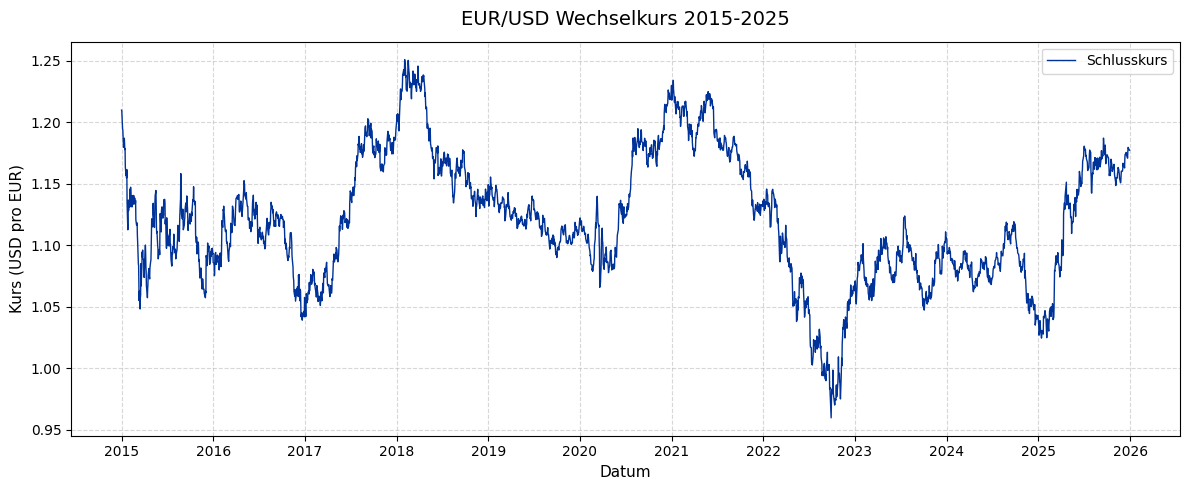

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eurusd.index, eurusd["Close"], color="#003399", linewidth=1.0, label="Schlusskurs")
ax.set_title("EUR/USD Wechselkurs 2015-2025", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Kurs (USD pro EUR)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Erste Beobachtungen

_(Hier kommen Alpers Beobachtungen rein)_

---
## Schritt 2: Stationaritaetstest (ADF-Test)

- H0: Reihe hat Einheitswurzel (nicht stationaer)
- H1: Reihe ist stationaer

p-Wert < 0.05 -> stationaer

In [5]:
from statsmodels.tsa.stattools import adfuller

close = eurusd["Close"].dropna()

result = adfuller(close)
print("=== ADF-Test auf die EUR/USD-Reihe ===")
print(f"ADF-Statistik : {result[0]:.4f}")
print(f"p-Wert        : {result[1]:.4f}")
print("Kritische Werte:")
for key, val in result[4].items():
    print(f"  {key}: {val:.4f}")

if result[1] < 0.05:
    print("\n-> Reihe ist stationaer")
else:
    print("\n-> Reihe ist NICHT stationaer -> Differenzierung erforderlich")

=== ADF-Test auf die EUR/USD-Reihe ===
ADF-Statistik : -2.9934
p-Wert        : 0.0355
Kritische Werte:
  1%: -3.4326
  5%: -2.8626
  10%: -2.5673

-> Reihe ist stationaer


---
## Schritt 3: Differenzierung

Wechselkurse sind typischerweise nicht stationaer. Wir differenzieren einmal (d=1).

=== ADF-Test auf differenzierte Reihe ===
ADF-Statistik : -23.1577
p-Wert        : 0.0000

-> Differenzierte Reihe ist stationaer -> d = 1


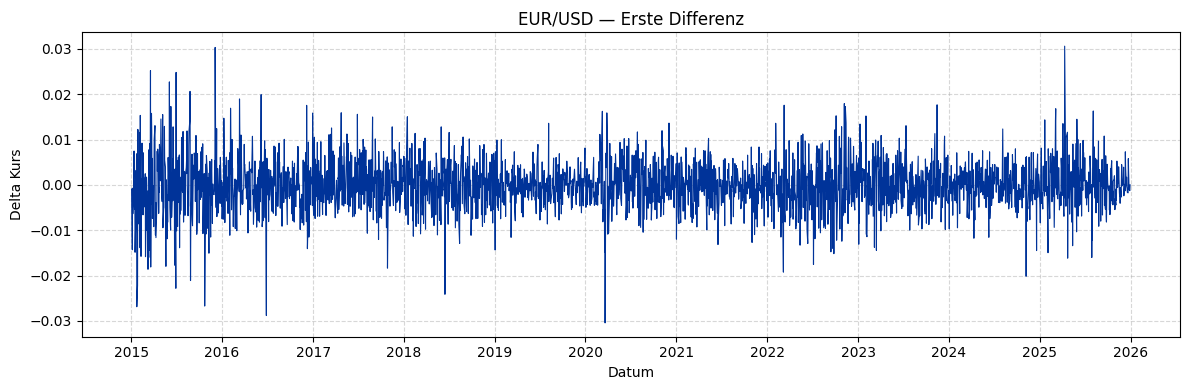

In [6]:
close_diff = close.diff().dropna()

result_diff = adfuller(close_diff)
print("=== ADF-Test auf differenzierte Reihe ===")
print(f"ADF-Statistik : {result_diff[0]:.4f}")
print(f"p-Wert        : {result_diff[1]:.4f}")

if result_diff[1] < 0.05:
    print("\n-> Differenzierte Reihe ist stationaer -> d = 1")
else:
    print("\n-> Weitere Differenzierung notwendig")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(close_diff.index, close_diff.values, color="#003399", linewidth=0.8)
ax.set_title("EUR/USD — Erste Differenz")
ax.set_xlabel("Datum")
ax.set_ylabel("Delta Kurs")
ax.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

---
## Schritt 4: ACF & PACF

- **ACF** -> MA-Ordnung (q)
- **PACF** -> AR-Ordnung (p)

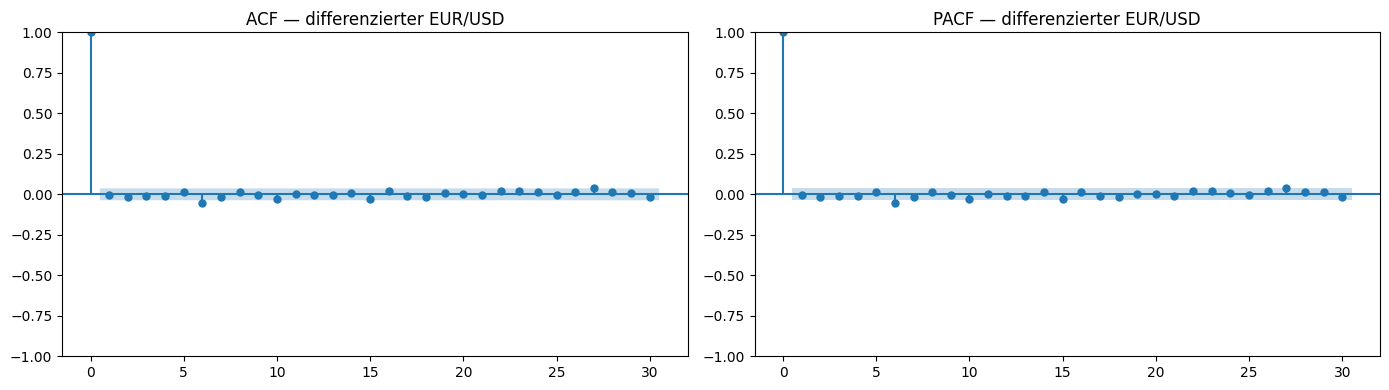

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(close_diff, lags=30, ax=axes[0])
axes[0].set_title("ACF — differenzierter EUR/USD")

plot_pacf(close_diff, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF — differenzierter EUR/USD")

plt.tight_layout()
plt.show()

---
## Schritt 5: Modellauswahl (p, d, q)

Grid search ueber Kandidatenmodelle. Niedrigeres AIC = besseres Modell.

In [8]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

best_aic = np.inf
best_order = None
best_model = None

candidates = [(p, 1, q) for p in range(0, 4) for q in range(0, 4)]

print("Modellvergleich (AIC):")
print("-" * 30)

for order in candidates:
    try:
        model = ARIMA(close, order=order).fit()
        print(f"ARIMA{order}  AIC: {model.aic:.2f}")
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = order
            best_model = model
    except:
        pass

print(f"\n-> Bestes Modell: ARIMA{best_order} mit AIC = {best_aic:.2f}")

Modellvergleich (AIC):
------------------------------
ARIMA(0, 1, 0)  AIC: -21628.49
ARIMA(0, 1, 1)  AIC: -21626.61
ARIMA(0, 1, 2)  AIC: -21625.37
ARIMA(0, 1, 3)  AIC: -21623.91
ARIMA(1, 1, 0)  AIC: -21626.61
ARIMA(1, 1, 1)  AIC: -21624.48
ARIMA(1, 1, 2)  AIC: -21623.95
ARIMA(1, 1, 3)  AIC: -21621.93
ARIMA(2, 1, 0)  AIC: -21625.35
ARIMA(2, 1, 1)  AIC: -21625.84
ARIMA(2, 1, 2)  AIC: -21620.48
ARIMA(2, 1, 3)  AIC: -21620.30
ARIMA(3, 1, 0)  AIC: -21623.87
ARIMA(3, 1, 1)  AIC: -21621.87
ARIMA(3, 1, 2)  AIC: -21619.87
ARIMA(3, 1, 3)  AIC: -21620.02

-> Bestes Modell: ARIMA(0, 1, 0) mit AIC = -21628.49


In [9]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2862
Model:                 ARIMA(0, 1, 0)   Log Likelihood               10815.244
Date:                Sun, 10 May 2026   AIC                         -21628.488
Time:                        10:42:13   BIC                         -21622.529
Sample:                             0   HQIC                        -21626.339
                               - 2862                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      3.047e-05   5.33e-07     57.214      0.000    2.94e-05    3.15e-05
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):               789.49
Prob(Q):                              0.73   Pr

---
## Schritt 6: Residualdiagnostik

Ein gutes Modell hinterlaesst weisse Residuen ohne Autokorrelation.

- Zeitplot der Residuen
- ACF der Residuen
- Ljung-Box-Test

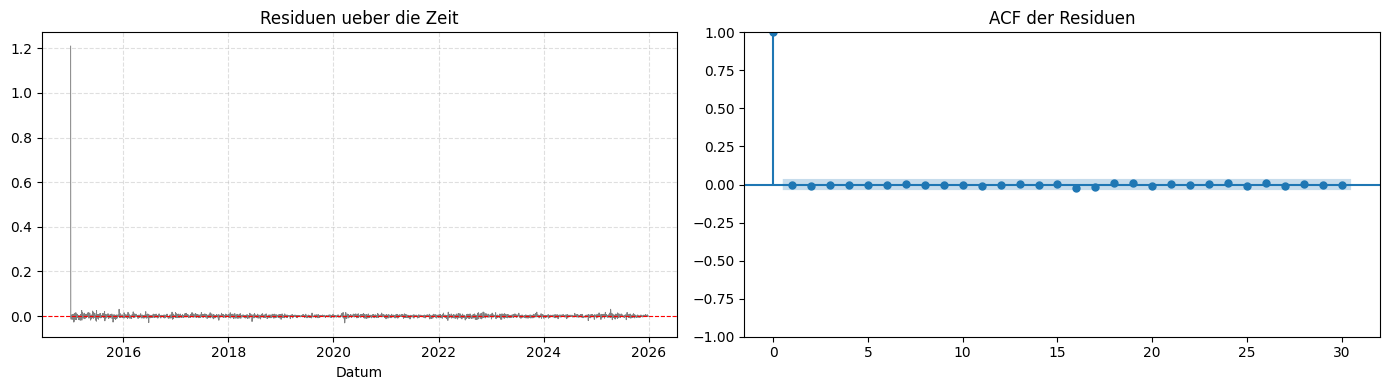

=== Ljung-Box-Test ===
     lb_stat  lb_pvalue
10  0.761969   0.999951
20  3.970783   0.999956

(p > 0.05 -> keine signifikante Autokorrelation in den Residuen)


In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = best_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals.index, residuals.values, color="gray", linewidth=0.7)
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].set_title("Residuen ueber die Zeit")
axes[0].set_xlabel("Datum")
axes[0].grid(True, linestyle="--", alpha=0.4)

plot_acf(residuals, lags=30, ax=axes[1])
axes[1].set_title("ACF der Residuen")

plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("=== Ljung-Box-Test ===")
print(lb_test)
print("\n(p > 0.05 -> keine signifikante Autokorrelation in den Residuen)")

---
## Schritt 7: Prognose

30-Tage-Prognose mit 95% Vorhersageintervall.

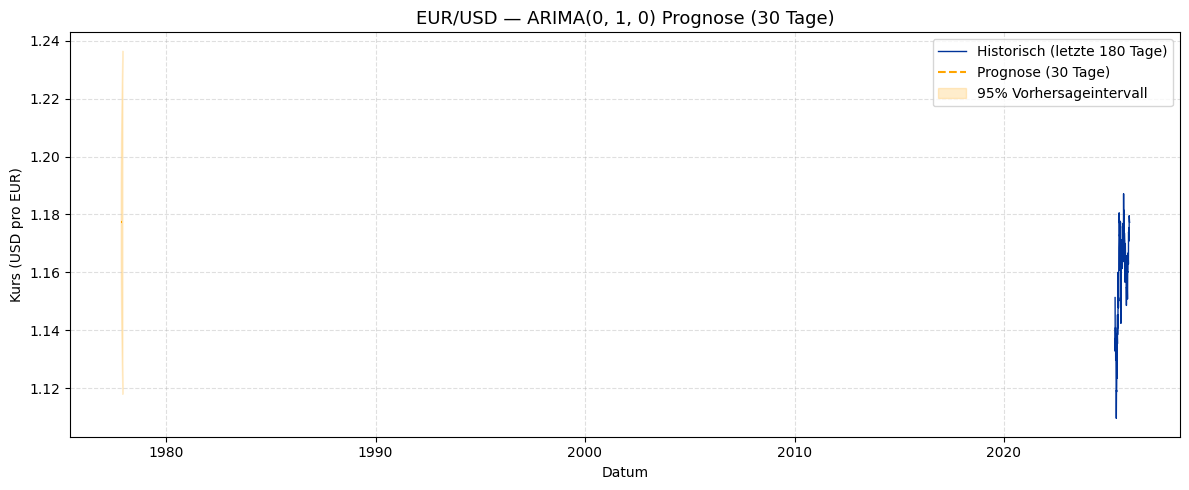


=== Prognosewerte ===
      Prognose    CI_low   CI_high
2862  1.177288  1.166468  1.188107
2863  1.177288  1.161987  1.192589
2864  1.177288  1.158548  1.196027
2865  1.177288  1.155649  1.198927
2866  1.177288  1.153095  1.201481
2867  1.177288  1.150786  1.203790
2868  1.177288  1.148663  1.205913
2869  1.177288  1.146686  1.207890
2870  1.177288  1.144830  1.209746
2871  1.177288  1.143074  1.211502
2872  1.177288  1.141404  1.213172
2873  1.177288  1.139808  1.214767
2874  1.177288  1.138278  1.216298
2875  1.177288  1.136806  1.217770
2876  1.177288  1.135385  1.219191
2877  1.177288  1.134010  1.220565
2878  1.177288  1.132678  1.221897
2879  1.177288  1.131385  1.223190
2880  1.177288  1.130127  1.224448
2881  1.177288  1.128902  1.225673
2882  1.177288  1.127707  1.226868
2883  1.177288  1.126541  1.228035
2884  1.177288  1.125400  1.229176
2885  1.177288  1.124284  1.230292
2886  1.177288  1.123191  1.231385
2887  1.177288  1.122120  1.232456
2888  1.177288  1.121069  1.2335

In [11]:
forecast_steps = 30
forecast = best_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(close[-180:].index, close[-180:].values,
        color="#003399", linewidth=1.0, label="Historisch (letzte 180 Tage)")

ax.plot(forecast_mean.index, forecast_mean.values,
        color="orange", linewidth=1.5, linestyle="--", label="Prognose (30 Tage)")

ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color="orange", alpha=0.2, label="95% Vorhersageintervall")

ax.set_title(f"EUR/USD — ARIMA{best_order} Prognose (30 Tage)", fontsize=13)
ax.set_xlabel("Datum")
ax.set_ylabel("Kurs (USD pro EUR)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n=== Prognosewerte ===")
print(pd.DataFrame({"Prognose": forecast_mean, "CI_low": forecast_ci.iloc[:,0], "CI_high": forecast_ci.iloc[:,1]}))